In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from collections.abc import Hashable
from typing import NamedTuple, Generator, Callable
from anndata import AnnData
from itertools import product
from tqdm import tqdm

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
from numpy.typing import NDArray
from pandas import DataFrame, Series
from scipy.stats import spearmanr, pearsonr
import torch

from utils import (
    sort_df,
    filter_celltypes_by_size,
    group_by_common_obs, 
    mean_randomized_cross_feature_prediction
)
from nmf_utils import nmf_predictor
from nn_utils import nn_predictor
from tangram_utils import tangram_predictor

In [3]:
def _adata_sp() -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    #adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype].copy()
    return adata_sp

def _adata_sc() -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    #adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype].copy()
    adata_sc.X = adata_sc.X.toarray()
    return adata_sc

adata_sp, adata_sc = _adata_sp(), _adata_sc()
data = (adata_sp, adata_sc)
data = tuple(filter_celltypes_by_size(adata, "celltype", 20) for adata in data)

for adata in data:
    assert isinstance(adata.X, np.ndarray)
    sc.pp.filter_genes(adata, min_counts=1)

shared_genes = np.intersect1d(*tuple(adata.var_names for adata in data))
celltypes = [celltype for celltype, _, _ in group_by_common_obs(*data, "celltype")]

print(f"{data=}")
print(f"{len(shared_genes)=}")

data=(AnnData object with n_obs × n_vars = 7386 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts', AnnData object with n_obs × n_vars = 2194 × 21094
    obs: 'cluster', 'celltype'
    var: 'n_counts')
len(shared_genes)=202


In [4]:
from disk_cache import disk_cache
from nn_utils import vae_predictor

methods = {
    "nmf": disk_cache(Path("data/cache/benchmarking_refactor/nmf"))(nmf_predictor),
    "tangram": disk_cache(Path("data/cache/benchmarking_refactor/tangram"))(tangram_predictor),
    "nn": disk_cache(Path("data/cache/benchmarking_refactor/nn"))(nn_predictor),
    "vae": disk_cache(Path("data/cache/benchmarking_refactor/vae"))(vae_predictor),
}

In [5]:
def make_celltype_score_function(
    adata_query: AnnData,
    adata_reference: AnnData,
    prediction_methods: dict[str, Callable[[NDArray, NDArray], NDArray]],
    correlation_function: Callable[[NDArray, NDArray], float],
    gene_set: NDArray[np.str_],
) -> Callable[[str, str], float]:
    def compute_score_for_celltype_and_method(
        celltype: str,
        method_name: str
    ) -> float:
        predictor = prediction_methods[method_name]
        query_matrix, reference_matrix = tuple(map(
            lambda adata: adata[adata.obs["celltype"] == celltype, gene_set].X,
            (adata_query, adata_reference)
        ))
        predicted_counts = mean_randomized_cross_feature_prediction(
            query_matrix,
            reference_matrix,
            predictor,
            iterations=10,
            seed=5
        )
        score = correlation_function(
            query_matrix,
            predicted_counts
        )
        return score

    return compute_score_for_celltype_and_method

In [6]:
def score_celltype_prediction(
    celltype: str,
    method_name: str
) -> float:
    predictor = methods[method_name]
    query_matrix, reference_matrix = tuple(map(
        lambda adata: adata[adata.obs["celltype"] == celltype, shared_genes].X,
        (adata_sp, adata_sc)
    ))
    predicted_counts = mean_randomized_cross_feature_prediction(
        query_matrix,
        reference_matrix,
        predictor,
        iterations=10,
        seed=5
    )
    score = float(spearmanr(
        query_matrix.mean(axis=0),
        predicted_counts.mean(axis=0)
    )[0])
    return score

In [7]:
score_celltype_prediction = make_celltype_score_function(
    adata_sp,
    adata_sc,
    methods,
    lambda arr1, arr2: float(spearmanr(arr1.mean(axis=0), arr2.mean(axis=0))[0]),
    shared_genes
)

In [8]:
records = [
    (celltype, method_name, score_celltype_prediction(celltype, method_name)) 
    for celltype, method_name 
    in tqdm(product(celltypes, methods.keys()))
]
df = DataFrame(records, columns=["celltype", "method", "score"]).pivot_table(index="celltype", columns="method", values="score")
df = sort_df(df, np.median, axis=0)
df

3it [00:00, 10.28it/s]

convergence reached, training stopped at 100
convergence reached, training stopped at 120
convergence reached, training stopped at 120
convergence reached, training stopped at 110
convergence reached, training stopped at 60
convergence reached, training stopped at 110
convergence reached, training stopped at 100
convergence reached, training stopped at 110
convergence reached, training stopped at 120
convergence reached, training stopped at 70
convergence reached, training stopped at 100
convergence reached, training stopped at 110
convergence reached, training stopped at 110
convergence reached, training stopped at 70
convergence reached, training stopped at 140
convergence reached, training stopped at 140
convergence reached, training stopped at 110
convergence reached, training stopped at 60
convergence reached, training stopped at 130
convergence reached, training stopped at 100
convergence reached, training stopped at 60
convergence reached, training stopped at 120
convergence rea

5it [00:03,  1.30it/s]

convergence reached, training stopped at 120
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 60
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 60
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training s

8it [00:03,  2.01it/s]

...

60it [00:23,  3.02it/s]

convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 100
convergence reached, training stopped at 80
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 100
convergence reached, training stopped at 50
convergence reached, training stopped at 60
convergence reached, training stopped at 60
convergence reached, training stopped at 50
convergence reached, training stopped at 60
convergence reached, training stopped at 50
convergence reached, training stopped at 80
convergence reached, training stopped at 40
convergence reached, training 

64it [00:24,  2.60it/s]

convergence reached, training stopped at 40
convergence reached, training stopped at 130
convergence reached, training stopped at 60


method,nn,vae,nmf,tangram
celltype,,,,
BZE,0.605677,0.613944,0.623432,0.625569
Blood vasc.,0.530604,0.485291,0.670923,0.674293
Goblet,0.702200,0.671399,0.685049,0.685037
Lymphatic,0.474409,0.432765,0.547439,0.570311
MZE,0.568653,0.583092,0.651926,0.654945
Macrophage,0.677065,0.679330,0.729098,0.727853
Paneth,0.674549,0.691177,0.713820,0.708787
Plasma,0.541068,0.581681,0.623399,0.626489
Rest B,0.489636,0.506440,0.611213,0.620275


In [13]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


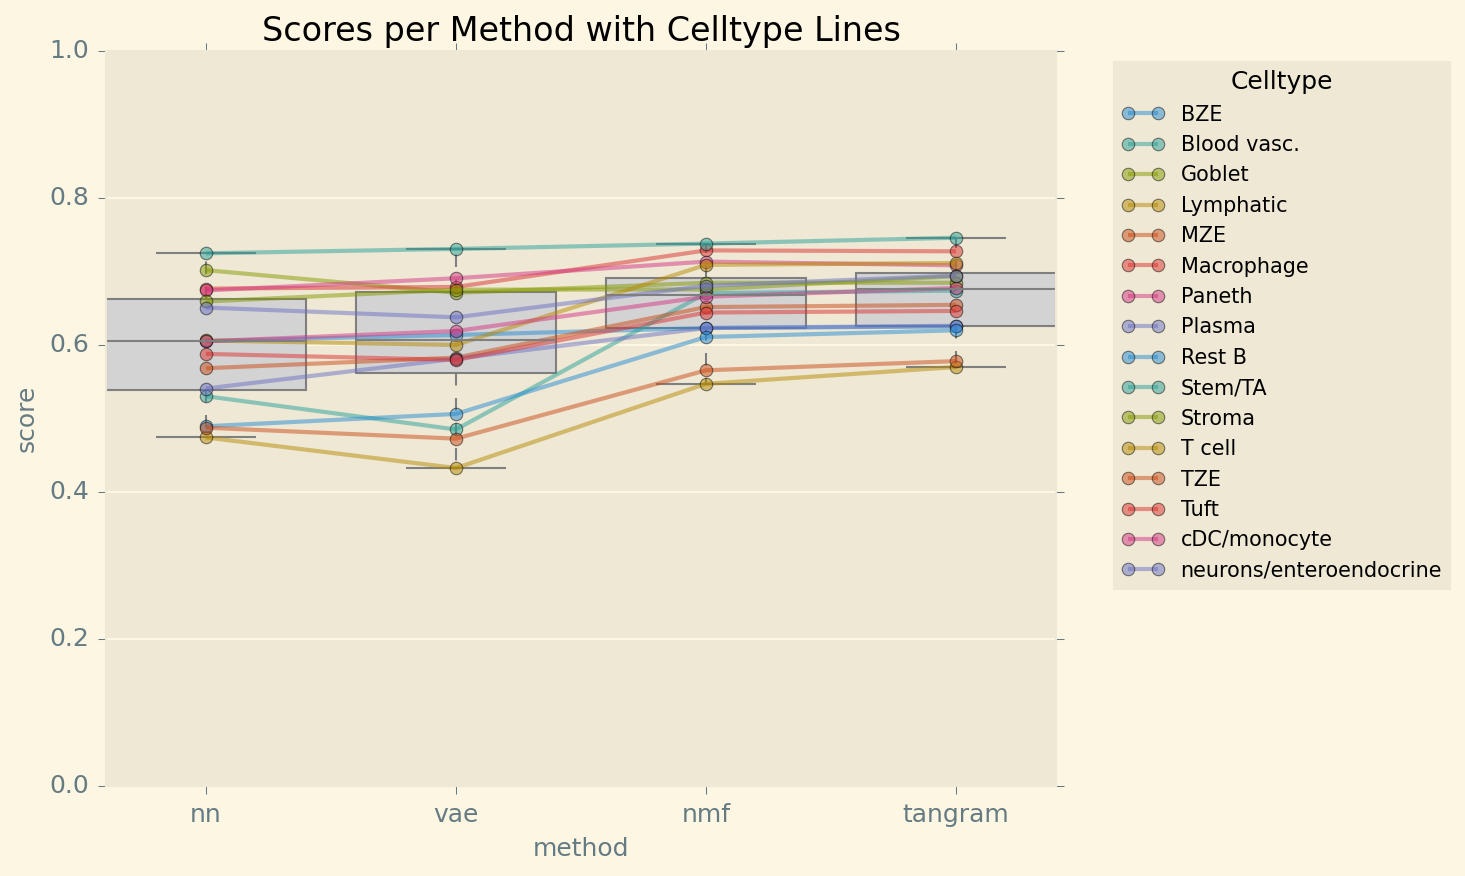

In [38]:
plt.style.use("Solarize_Light2")
df_reset = df.reset_index().melt(id_vars="celltype", var_name="method", value_name="score")
plt.figure(figsize=(10, 6), dpi=150)
sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")
    
for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)
    
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [10]:
functions = [
    ("mean_query", lambda celltype: adata_sp[adata_sp.obs["celltype"] == celltype][:, shared_genes].X.mean().item()),
    ("mean_reference", lambda celltype: adata_sc[adata_sc.obs["celltype"] == celltype][:, shared_genes].X.mean().item()),
    ("n_obs_query", lambda celltype: adata_sp[adata_sp.obs["celltype"] == celltype].n_obs),
    ("n_obs_reference", lambda celltype: adata_sc[adata_sc.obs["celltype"] == celltype].n_obs),
]
df_metrics = DataFrame(
    [{f_name: f(celltype) for f_name, f in functions} for celltype in celltypes],
    celltypes
)
df_metrics

,mean_query,mean_reference,n_obs_query,n_obs_reference
BZE,0.620815,0.657014,1755,325
Blood vasc.,0.392093,0.168317,148,33
Goblet,0.623795,0.791965,453,216
Lymphatic,0.340767,0.092650,1423,267
MZE,0.323398,0.598224,95,63
Macrophage,0.304448,0.610802,351,89
Paneth,0.838302,2.795753,184,128
Plasma,0.547466,0.596971,437,85
Rest B,0.389484,0.196814,37,234
Stem/TA,0.549023,1.168517,997,420


In [11]:
test = df.join(df_metrics)
test

,nn,vae,nmf,tangram,mean_query,mean_reference,n_obs_query,n_obs_reference
celltype,,,,,,,,
BZE,0.605677,0.613944,0.623432,0.625569,0.620815,0.657014,1755,325
Blood vasc.,0.530604,0.485291,0.670923,0.674293,0.392093,0.168317,148,33
Goblet,0.702200,0.671399,0.685049,0.685037,0.623795,0.791965,453,216
Lymphatic,0.474409,0.432765,0.547439,0.570311,0.340767,0.092650,1423,267
MZE,0.568653,0.583092,0.651926,0.654945,0.323398,0.598224,95,63
Macrophage,0.677065,0.679330,0.729098,0.727853,0.304448,0.610802,351,89
Paneth,0.674549,0.691177,0.713820,0.708787,0.838302,2.795753,184,128
Plasma,0.541068,0.581681,0.623399,0.626489,0.547466,0.596971,437,85
Rest B,0.489636,0.506440,0.611213,0.620275,0.389484,0.196814,37,234


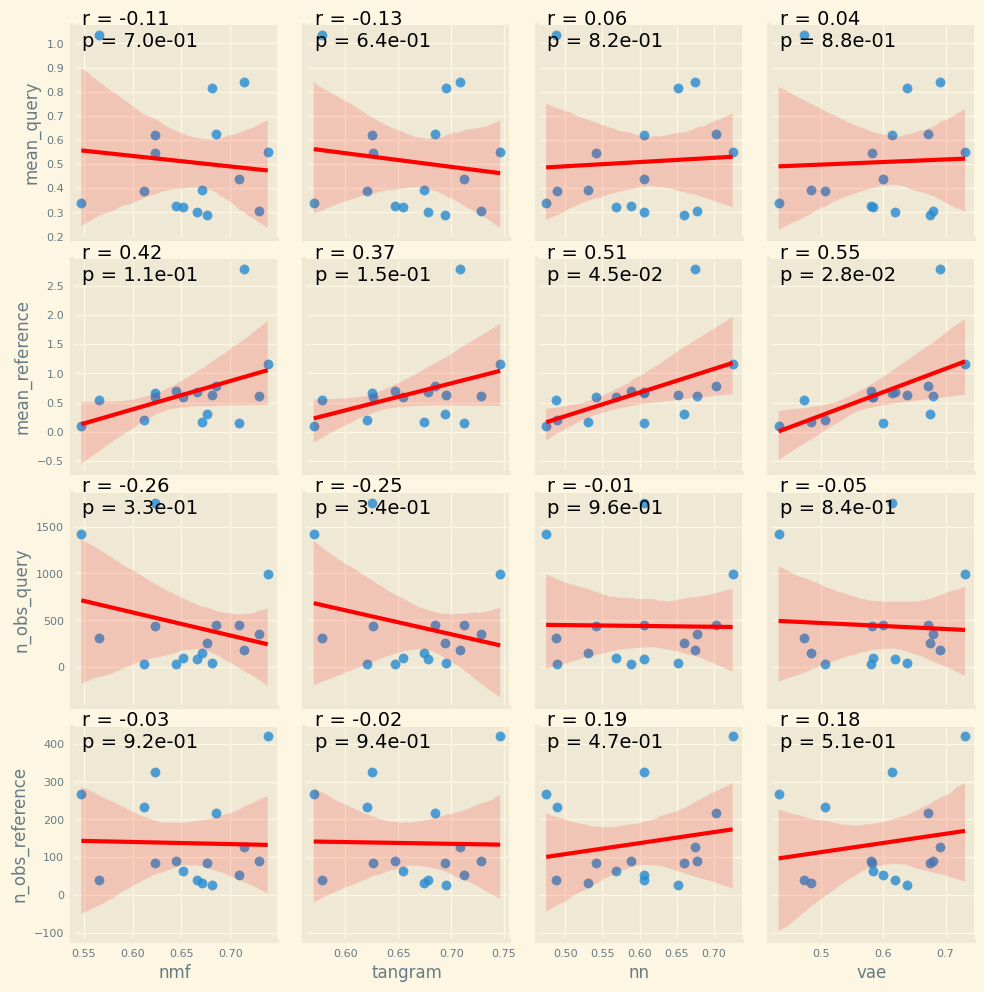

In [36]:
def scatter_with_corr(x, y, **kwargs):
    ax = plt.gca()
    sns.regplot(x=x, y=y, ax=ax, scatter_kws={"s": 50}, line_kws={"color": "red"})
    
    r, p = pearsonr(x, y)
    ax.annotate(f'r = {r:.2f}\np = {p:.1e}', xy=(0.05, 0.9), xycoords=ax.transAxes)

g = sns.PairGrid(
    test, 
    x_vars=[method_name for method_name, _ in methods.items()], 
    y_vars=[f_name for f_name, _ in functions],
)
g.map(scatter_with_corr)

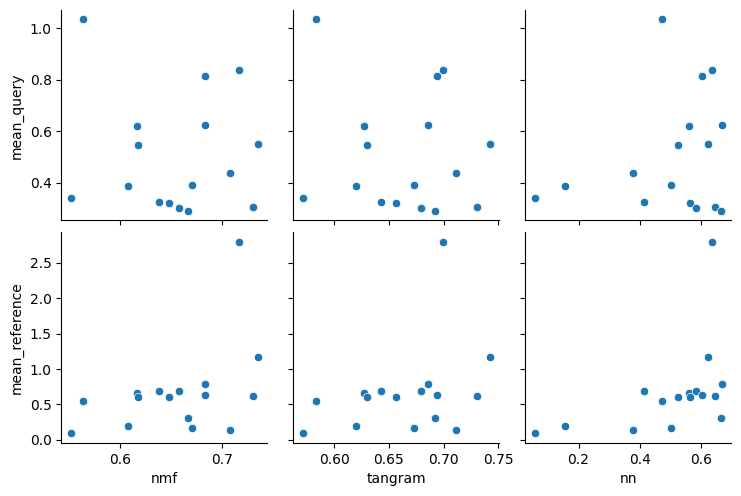

In [128]:
sns.pairplot(
    test, 
    x_vars=[method_name for method_name, _ in methods.items()], 
    y_vars=[f_name for f_name, _ in functions],
)

In [103]:
from itertools import combinations


for a, b in product([1,2], ["a", "b", "c"]):
    print(a, b)

1 a
1 b
1 c
2 a
2 b
2 c


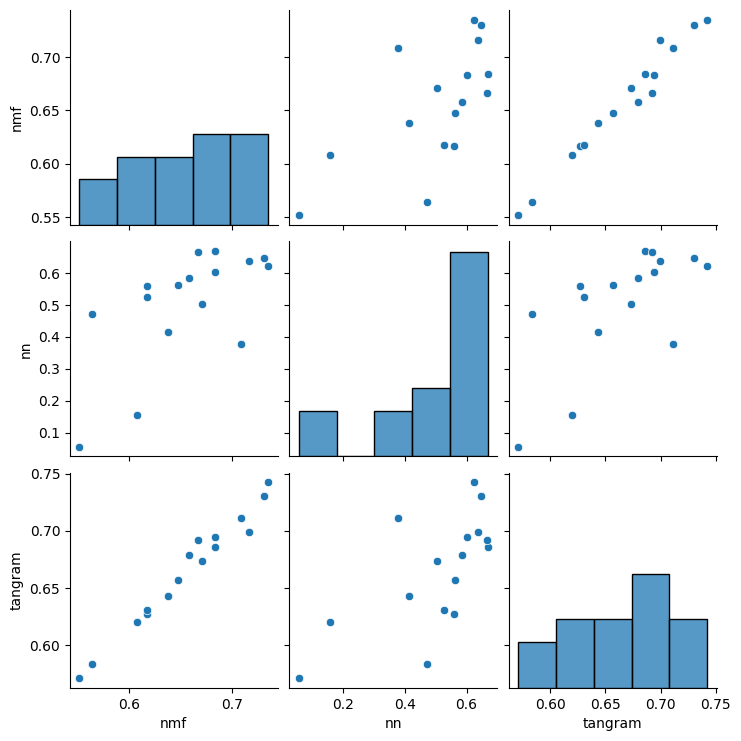

In [92]:
sns.pairplot(df_pivot)

In [89]:
df_metrics["mean_query"]

BZE                         0.6208146
Blood vasc.                 0.3920926
Goblet                     0.62379515
Lymphatic                   0.3407666
MZE                         0.3233976
Macrophage                  0.3044484
Paneth                      0.8383018
Plasma                     0.54746586
Rest B                     0.38948354
Stem/TA                    0.54902333
Stroma                      0.2912382
T cell                      0.4369475
TZE                          1.034316
Tuft                       0.32728273
cDC/monocyte               0.30310532
neurons/enteroendocrine      0.815144
Name: mean_query, dtype: object

In [90]:
df_pivot = df.pivot_table(index="celltype", columns="method", values="score")

In [28]:
from typing import Any, Literal
from nn_utils import converged
import torch
import torch.nn as nn
import torch.nn.functional as F

def reparameterize(
    mu: torch.Tensor,
    std: torch.Tensor
):
    return mu

class SampledNormalLayer(nn.Module):
    def __init__(
        self, 
        layer_mu: nn.Module, 
        layer_std: nn.Module, 
    ):
        super().__init__()
        self.layer_mu = layer_mu
        self.layer_std = layer_std

    def forward(
        self,
        x,
    ):
        mu = self.layer_mu(x)
        std = self.layer_std(x)
        res = reparameterize(mu, std)
        return res

class VAE(nn.Module):
    def __init__(
        self,
        input_tensor: torch.Tensor,
        n_latent: int,
        target_tensor: torch.Tensor
    ) -> None:
        super().__init__()
        self.input_tensor = input_tensor
        self.target_tensor = target_tensor

        n_input = input_tensor.shape[1]
        n_output = target_tensor.shape[1]

        self.mu = nn.Linear(n_input, n_latent)
        self.std = nn.Linear(n_input, n_latent)
        self.sampling_layer = SampledNormalLayer(
            self.mu,
            self.std
        )
        self.fc2 = nn.Linear(n_latent, n_output)

    def forward(
        self, 
        x: torch.Tensor, 
        mode: Literal["eval", "train"] = "eval"
    ) -> torch.Tensor:
        #x = F.relu(self.fc1(x))
        x = {
            "eval": self.mu,
            "train": self.sampling_layer,
        }[mode](x)
        x = F.relu(x)

        return self.fc2(x)

    def train(
        self,
        optimizer: Callable[..., torch.optim.Optimizer],
        lr: float,
        loss_fn: Any,
        max_n_epochs: int,
        verbose: bool = False
    ) -> list[float]:
        optimizer = optimizer(self.parameters(), lr=lr)
        losses = []
        window = 10
        for epoch in range(max_n_epochs):
            output = self(self.input_tensor, mode="train")
            loss = loss_fn(output, self.target_tensor)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            if epoch % window == 0 and converged(losses, window=window, cutoff=5e-1):
                print(f"convergence reached, training stopped at {epoch}")
                break
        if verbose:
            print(f"training stopped at {max_n_epochs=}")
        return losses

In [29]:
def vae_predictor(
    query_matrix: NDArray,
    reference_matrix: NDArray,
    *args,
    **kwargs,
) -> NDArray:

    n_shared_genes = query_matrix.shape[1]
    input_tensor, target_tensor = (torch.Tensor(arr) for arr in np.hsplit(reference_matrix, [n_shared_genes]))
    model = VAE(input_tensor, 10, target_tensor)
    model.train(
        torch.optim.Adam,
        1e-1,
        torch.nn.MSELoss(),
        1000,
        *args,
        **kwargs,
    )
    query_tensor  = torch.Tensor(query_matrix)
    predicted_counts = model(query_tensor)
    return predicted_counts.detach().numpy()

In [30]:
query_matrix, reference_matrix = map(
    lambda adata: adata[:, shared_genes].X,
    data
)

In [31]:
from utils import cross_feature_prediction


cross_feature_prediction(
    query_matrix,
    reference_matrix,
    vae_predictor
)

array([[ 3.4945932e-01,  9.1985524e-02, -6.0613297e-02, ...,
         2.9835248e+00,  9.7909942e-02,  1.7657458e+00],
       [ 3.4529901e-01,  7.4822674e+00, -5.8727559e-02, ...,
         2.9835248e+00,  9.7909942e-02,  1.7657458e+00],
       [ 3.2607853e-01,  4.1625095e+01, -5.0015524e-02, ...,
         2.9835248e+00,  9.7909942e-02,  1.7657458e+00],
       ...,
       [ 4.4087735e-01,  8.3906375e-02, -3.6151178e-02, ...,
         2.5811839e-01,  8.7031133e-02,  1.7619145e+00],
       [ 3.9973858e-01,  8.4250815e-02,  7.4102230e-02, ...,
         2.9835248e+00,  9.7909942e-02,  1.7657458e+00],
       [ 3.9359328e-01,  8.8085145e-02, -4.8803698e-02, ...,
         5.7339783e+00,  7.1608670e-02,  1.3363646e+00]], dtype=float32)

In [19]:
from utils import split_into_parts


for input, output in split_into_parts(shared_genes, 3):
    input_tensor = torch.Tensor(adata_sc[:, input].X)
    target_tensor = torch.Tensor(adata_sc[:, output].X)

In [20]:
from nn_utils import Model


def nn_predictor_parameter_optimization(
    n_latent,
    lr
) -> NDArray:
    model = Model(input_tensor, n_latent, target_tensor)
    losses = model.train(
        torch.optim.Adam,
        lr,
        torch.nn.MSELoss(),
        100000,
        convergence_cutoff=-0.01
    )
    return losses

In [45]:
final_loss = nn_predictor_parameter_optimization(3, 0.1)[-1]
final_loss

convergence reached, training stopped at 70


17.124814987182617

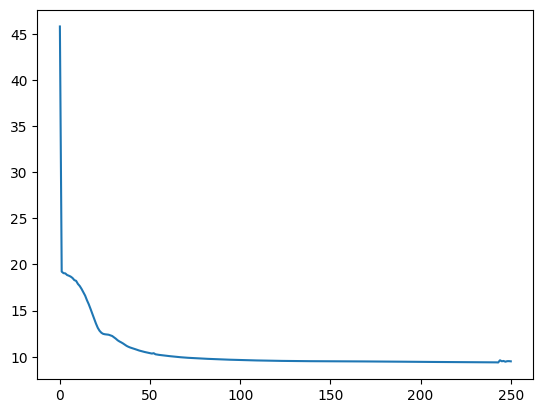

In [61]:
plt.plot(losses)

In [14]:
intrinsic_dimensionality_mle(adata_sc[:, shared_genes].X)

np.float64(9.681466693179077)

In [25]:
len(losses)

321